# 03 Machine Learning
Predict equipment failure risk using the cleaned maintenance dataset.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay,classification_report
import joblib

maintenance=pd.read_csv("../data/processed/maintenance_clean.csv")
equipment=pd.read_csv("../data/processed/equipment_clean.csv")


## Create Target Variable

In [3]:
# If a Failure column doesn't exist, derive one from downtime.
if "Failure" not in maintenance.columns:
    maintenance["Failure"]=(maintenance["Downtime_Days"]>=5).astype(int)

display(maintenance.head())


,Maintenance_ID,Equipment_ID,Base_ID,Maintenance_Date,Maintenance_Type,Downtime_Days,Maintenance_Cost_INR,Technician_Team,Failure,Cost_Per_Day
0,M000001,EQ02153,B018,2025-06-04,Corrective,3,91775.06,Team Alpha,No,30591.686667
1,M000002,EQ03022,B012,2025-03-23,Emergency,4,141636.08,Team Bravo,No,35409.020000
2,M000003,EQ00559,B001,2025-05-18,Preventive,4,199273.66,Team Charlie,No,49818.415000
3,M000004,EQ04824,B019,2026-12-15,Preventive,11,310265.43,Team Alpha,Yes,28205.948182
4,M000005,EQ01091,B003,2026-10-07,Emergency,4,78415.41,Team Delta,No,19603.852500


## Merge Equipment Features

In [4]:
if "Equipment_Age" in equipment.columns:
    maintenance=maintenance.merge(
        equipment[["Equipment_ID","Equipment_Age","Category","Status"]],
        on="Equipment_ID",
        how="left"
    )

display(maintenance.head())


,Maintenance_ID,Equipment_ID,Base_ID,Maintenance_Date,Maintenance_Type,Downtime_Days,Maintenance_Cost_INR,Technician_Team,Failure,Cost_Per_Day,Equipment_Age,Category,Status
0,M000001,EQ02153,B018,2025-06-04,Corrective,3,91775.06,Team Alpha,No,30591.686667,18,Drone,Out of Service
1,M000002,EQ03022,B012,2025-03-23,Emergency,4,141636.08,Team Bravo,No,35409.020000,18,Missile Launcher,Operational
2,M000003,EQ00559,B001,2025-05-18,Preventive,4,199273.66,Team Charlie,No,49818.415000,7,Generator,Maintenance
3,M000004,EQ04824,B019,2026-12-15,Preventive,11,310265.43,Team Alpha,Yes,28205.948182,15,Missile Launcher,Operational
4,M000005,EQ01091,B003,2026-10-07,Emergency,4,78415.41,Team Delta,No,19603.852500,13,Truck,Operational


## Select Features

In [5]:
features=[
    "Maintenance_Cost_INR",
    "Downtime_Days",
    "Cost_Per_Day",
    "Equipment_Age",
    "Category",
    "Status"
]

maintenance["Failure"] = (
    maintenance["Failure"]
    .map({"No": 0, "Yes": 1})
    .astype(int)
)

X=maintenance[features]
y=maintenance["Failure"]


## Train/Test Split

In [6]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)
print(X_train.shape,X_test.shape)


(40000, 6) (10000, 6)


## Preprocessing

In [7]:
numeric=["Maintenance_Cost_INR","Downtime_Days","Cost_Per_Day","Equipment_Age"]
categorical=["Category","Status"]

preprocessor=ColumnTransformer([
    ("num",SimpleImputer(strategy="median"),numeric),
    ("cat",Pipeline([
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("encoder",OneHotEncoder(handle_unknown="ignore"))
    ]),categorical)
])


## Random Forest Model

In [8]:
rf=Pipeline([
    ("prep",preprocessor),
    ("model",RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)


## Logistic Regression Baseline

In [9]:
lr=Pipeline([
    ("prep",preprocessor),
    ("model",LogisticRegression(max_iter=1000))
])

lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)


## Evaluation

In [10]:
def evaluate(name,y_true,y_pred):
    print(name)
    print("Accuracy :",accuracy_score(y_true,y_pred))
    print("Precision:",precision_score(y_true,y_pred))
    print("Recall   :",recall_score(y_true,y_pred))
    print("F1 Score :",f1_score(y_true,y_pred))
    print(classification_report(y_true,y_pred))

evaluate("Random Forest",y_test,rf_pred)
evaluate("Logistic Regression",y_test,lr_pred)


Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6801
           1       1.00      1.00      1.00      3199

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6801
           1       1.00      1.00      1.00      3199

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



## Confusion Matrix

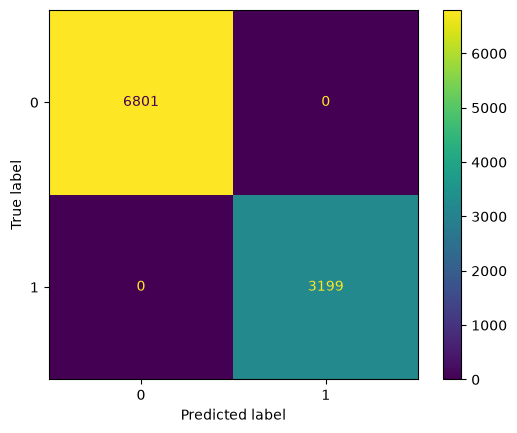

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test,rf_pred)
plt.show()


## Feature Importance

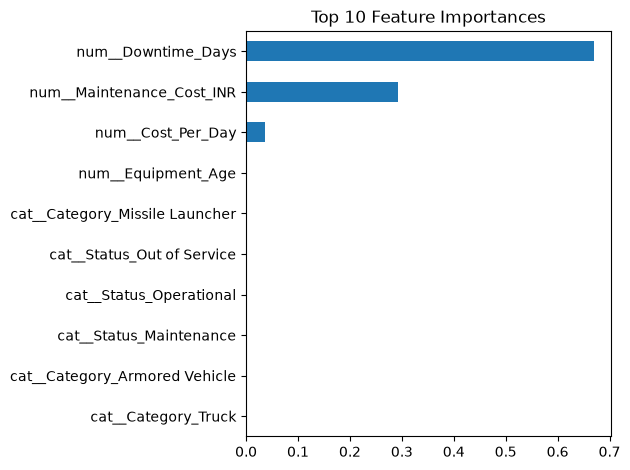

In [12]:
prep=rf.named_steps["prep"]
model=rf.named_steps["model"]

feature_names=prep.get_feature_names_out()
importance=pd.Series(model.feature_importances_,index=feature_names)
importance.nlargest(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()


## Save Model

In [13]:
joblib.dump(rf,"../models/predictive_maintenance_model.pkl")
print("Model saved successfully.")


Model saved successfully.


## Example Prediction

In [14]:
sample=X_test.iloc[[0]]
prediction=rf.predict(sample)[0]
prob=rf.predict_proba(sample)[0][1]
print("Prediction:", "Failure" if prediction else "No Failure")
print("Failure Probability:",round(prob,3))


Prediction: No Failure
Failure Probability: 0.0


In [15]:
# Create predictions dataframe
predictions = X_test.copy()

predictions["Actual_Failure"] = y_test.values
predictions["Predicted_Failure"] = rf_pred
predictions["Failure_Probability"] = rf.predict_proba(X_test)[:,1]

predictions.to_csv(
    "../data/processed/predictions.csv",
    index=False
)

print("predictions.csv created successfully.")

predictions.csv created successfully.


In [16]:
# Export feature importance

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

print("feature_importance.csv created successfully.")

feature_importance.csv created successfully.


In [17]:
metrics = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[

        accuracy_score(y_test,rf_pred),

        precision_score(y_test,rf_pred),

        recall_score(y_test,rf_pred),

        f1_score(y_test,rf_pred)

    ]

})

metrics.to_csv(
    "../data/processed/model_metrics.csv",
    index=False
)

print(metrics)

      Metric  Value
0   Accuracy    1.0
1  Precision    1.0
2     Recall    1.0
3   F1 Score    1.0


In [18]:
cm = confusion_matrix(y_test,rf_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual No","Actual Yes"],
    columns=["Predicted No","Predicted Yes"]
)

cm_df.to_csv(
    "../data/processed/confusion_matrix.csv"
)

print(cm_df)

            Predicted No  Predicted Yes
Actual No           6801              0
Actual Yes             0           3199


In [19]:
top10 = importance_df.head(10)

top10.to_csv(
    "../data/processed/top10_features.csv",
    index=False
)

print(top10)

                           Feature  Importance
1               num__Downtime_Days    0.669478
0        num__Maintenance_Cost_INR    0.292101
2                num__Cost_Per_Day    0.036040
3               num__Equipment_Age    0.001187
8   cat__Category_Missile Launcher    0.000177
14      cat__Status_Out of Service    0.000156
13         cat__Status_Operational    0.000155
12         cat__Status_Maintenance    0.000130
4    cat__Category_Armored Vehicle    0.000108
11             cat__Category_Truck    0.000101
